<a href="https://colab.research.google.com/github/mochamadx5/MachineLearning_11_MochamadReza/blob/main/JS05/JS05_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
from sklearn.datasets import make_classification

In [5]:
# Membuat data dummy
# Hasil dari make_classification berupa data fitur X dan label y
# Label y akan berupa data yang sudah di encode (angka)
x, y = make_classification(n_samples=30, n_features=2, n_classes=2,
n_informative=2, n_redundant=0, n_repeated=0, shuffle=False)

# Secara default, make_classfication menghasilkan nilai float
# Kita perlu merubah dalam bentuk diskrit

# Absolutekan nilai
x = np.absolute(x)

# bulatkan nilai ke 2 angka dibelakang koma
# kalikan dengan 100
x = np.round(x, 2) * 100

# ubahke dalam bentuk integer
x = x.astype(int)

# cek hasil
print(x)
print(y)

[[234 143]
 [195  22]
 [221 132]
 [162 154]
 [234  92]
 [ 82  54]
 [ 20 150]
 [154 123]
 [159  57]
 [  7 153]
 [ 10 204]
 [184  89]
 [ 28 218]
 [188  19]
 [174 196]
 [114 132]
 [ 30 240]
 [ 78 133]
 [256  95]
 [165  35]
 [ 85 100]
 [276  90]
 [ 90  95]
 [ 46 144]
 [ 32  92]
 [ 64  92]
 [ 94  79]
 [ 60 213]
 [  6 160]
 [114 132]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


In [15]:
import pandas as pd
# Reshape label y menjadi 2D
# Hal ini dilakukan karena kita akan menggabungkannya dengan data fitur X
y_new = y.reshape(-1, 1)

# Gabungkan data fitur X dan label y
data = np.concatenate((x, y_new), axis=1)

#defnisikan nama kolom
nama_kolom = ['Fitur 1', 'Fitur 2', 'Label']

# buat data frame
df = pd.DataFrame(data, columns=nama_kolom)

# cek hasil
df.head()

,Fitur 1,Fitur 2,Label
0,234,143,0
1,195,22,0
2,221,132,0
3,162,154,0
4,234,92,0


In [16]:
# definisikan nama label
labels = {
    1 : 'Kelas A',
    0 : 'Kelas B'
}
# Copy Data Frame untuk menyimpan Data Frame baru
# dengan label yang mudah untuk dibaca
df_label = df.copy()

# ubah label dengan fungsi dari pandas
# pada data frame df_label
df_label['Label'] = df_label['Label'].map(labels)

# cek hasil
df_label.head()

,Fitur 1,Fitur 2,Label
0,234,143,Kelas B
1,195,22,Kelas B
2,221,132,Kelas B
3,162,154,Kelas B
4,234,92,Kelas B


Text(0.5, 1.0, 'Visualisasi Data')

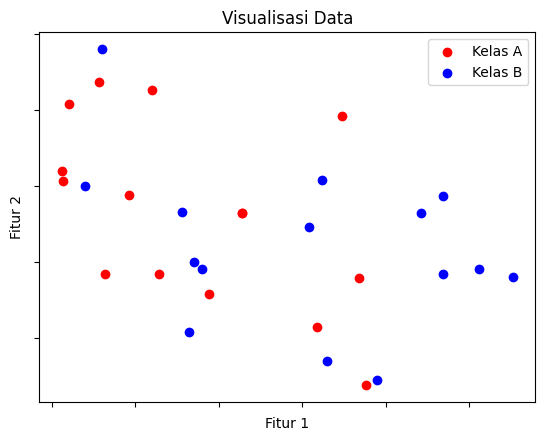

In [21]:
import matplotlib.pyplot as plt
# definisikan warna untuk setiap kelas
colors = {
    'kelas_A' : 'red',
    'kelas_B' : 'blue'
}

# kelompokkan label berdasarkan nama kelas (menggunakan string langsung untuk menghindari warning)
gb = df_label.groupby('Label')
kelas_A = gb.get_group('Kelas A')
kelas_B = gb.get_group('Kelas B')

# plot
plt.scatter(x = kelas_A['Fitur 1'], y= kelas_A['Fitur 2'], color=colors['kelas_A'])
plt.scatter(x = kelas_B['Fitur 1'], y= kelas_B['Fitur 2'], color=colors['kelas_B'])
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.legend(['Kelas A', 'Kelas B'])
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
plt.title('Visualisasi Data')